## Чекпоинт 7. Обучение модели с использованием mlflow для логирования.

### Используемая модель.
Мы будем использовать ExtraTreeClassifier, поскольку именно с его помощью удалось добиться наилучших результатов на предыдущих чекпоинтах. А именно -- F1-score = ~0.74.

In [ ]:
!pip3 install mlflow
!pip3 install minio
!pip3 install pandas
!pip3 install scikit-learn
!pip3 install matplotlib
!pip3 install seaborn
!pip3 install scikit-learn
!pip3 install boto3
!pip3 install seaborn

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.0/15.0 MB 9.5 MB/s  0:00:019.8 MB/s eta 0:00:0101
  Attempting uninstall: urllib3
    Found existing installation: urllib3 2.5.0
    Uninstalling urllib3-2.5.0:
      Successfully uninstalled urllib3-2.5.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [boto3]━━━━━ 2/5 [botocore]


In [2]:
# Проверим подключение к mlflow серверу

import mlflow

mlflow.set_tracking_uri("http://127.0.0.1:5000")

client = mlflow.tracking.MlflowClient()

try:
    experiments = client.search_experiments()
    print("MLflow connected")
    print("Experiments:", [exp.name for exp in experiments])
except Exception as e:
    print("MLflow connection failed")
    print(e)

MLflow connected
Experiments: ['Default']


In [15]:
# Проверим подключение к minio серверу

import boto3

s3 = boto3.client(
    "s3",
    endpoint_url="http://localhost:9000",
    aws_access_key_id="minioadmin",
    aws_secret_access_key="minioadmin",
)
bucket_name = 'checkpoint7'

try:
    s3.create_bucket(Bucket=bucket_name)        
except Exception as e:
    print(f"Ошибка при создании бакета: {e}")

try:
    response = s3.list_buckets()
    print("MinIO connected")
    print("Buckets:", [b["Name"] for b in response["Buckets"]])
except Exception as e:
    print("MinIO connection failed")
    print(e)

MinIO connected
Buckets: ['checkpoint7']


Подключения настроены, теперь обучим модель с логированием параметров в mlflow

In [20]:
import warnings
warnings.filterwarnings('ignore')

import joblib
import io

import numpy as np
import pandas as pd

from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import f1_score, accuracy_score, roc_auc_score, classification_report, confusion_matrix
from sklearn.ensemble import ExtraTreesClassifier

import matplotlib.pyplot as plt
import seaborn as sns


In [7]:
RANDOM_STATE = 42
N_ITER_RANDOM = 25
N_SPLITS = 5

mlflow.set_experiment('Checkpoint 7')

2026/06/03 21:52:21 INFO mlflow.tracking.fluent: Experiment with name 'Checkpoint 7' does not exist. Creating a new experiment.


<Experiment: artifact_location='/Users/imerochkin/maga/nba-predictor/mlruns_local/1', creation_time=1780512741925, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1780512741925, lifecycle_stage='active', name='Checkpoint 7', tags={}, trace_location=None, workspace='default'>

In [8]:
def get_data():
    df = pd.read_csv('model/features_engineered.csv')
    mlflow.log_params({
        'model': 'baseline',
        'n_iter_random': N_ITER_RANDOM,
        'n_splits': N_SPLITS,
        'random_state': RANDOM_STATE,
    })

    df.describe(include="all").to_csv("dataset_describe.csv")
    mlflow.log_artifact("dataset_describe.csv", artifact_path="data_description")

    recommended_features = [
        'elo_diff', 'home_elo_before', 'away_elo_before',
        
        'win_rate_diff_L20', 'win_rate_diff_L10', 'win_rate_diff_L5',
        'home_win_rate_L20', 'home_win_rate_L10', 'home_win_rate_L5',
        'away_win_rate_L20', 'away_win_rate_L10', 'away_win_rate_L5',
        
        'fg_pct_diff_L20', 'fg_pct_diff_L10', 'fg_pct_diff_L5',
        'fg3_pct_diff_L20', 'fg3_pct_diff_L10', 'fg3_pct_diff_L5',
        
        'h2h_home_win_rate', 'h2h_total_games',
        
        'is_home', 'season_progress',
    ]

    available_features = [f for f in recommended_features if f in df.columns]

    X = df[available_features].copy()
    y = df['home_win'].copy()

    mask = ~(X.isna().any(axis=1) | y.isna())
    X = X[mask]
    y = y[mask]

    mlflow.log_params({
        'n_games': len(X),
        'home_win_rate': y.mean(),
    })

    split_idx = int(len(X) * 0.8)
    X_train = X.iloc[:split_idx]
    X_test = X.iloc[split_idx:]
    y_train = y.iloc[:split_idx]
    y_test = y.iloc[split_idx:]

    return X_train, X_test, y_train, y_test

In [9]:
# Сначала поисследуем бейзлайн -- предсказание просто победы домашней команды во всех случаях

with mlflow.start_run(run_name='baseline'):
    # Загрузим и залогируем как артефакт в mlflow уже обработанные ранее данные

    X_train, X_test, y_train, y_test = get_data()

    y_pred_baseline = np.ones(len(y_test))
    y_pred_proba_baseline = np.ones(len(y_test))

    baseline_accuracy = accuracy_score(y_test, y_pred_baseline)
    baseline_roc_auc = roc_auc_score(y_test, y_pred_proba_baseline)
    baseline_f1 = f1_score(y_test, y_pred_baseline)

    mlflow.log_metrics({
        'accuracy': baseline_accuracy,
        'roc_auc': baseline_roc_auc,
        'f1_score': baseline_f1,
    })


🏃 View run baseline at: http://127.0.0.1:5000/#/experiments/1/runs/a9dcbb7553f74102adcd1d4ce1516b6b
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


In [10]:
# Убедимся, что запуск прошел успешно и эксперимент сохранился (в интерфейсе локально это так)

experiments = client.search_experiments()

for exp in experiments:
    print(exp)

<Experiment: artifact_location='/Users/imerochkin/maga/nba-predictor/mlruns_local/1', creation_time=1780512741925, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1780512741925, lifecycle_stage='active', name='Checkpoint 7', tags={}, trace_location=None, workspace='default'>
<Experiment: artifact_location='/Users/imerochkin/maga/nba-predictor/mlruns_local/0', creation_time=1780510979553, effective_trace_archival_retention=None, experiment_id='0', last_update_time=1780510979553, lifecycle_stage='active', name='Default', tags={}, trace_location=None, workspace='default'>


В интерфейсе mlflow видим в метриках:

accuracy: ~0.55

roc_auc: ~0.5

f1_score: ~0.7

Это наш бейзлайн

In [ ]:
# Теперь попробуем обучить модель ExtraTreesClassifier
from sklearn.model_selection import TimeSeriesSplit

with mlflow.start_run(run_name='ExtraTreesClassifier'):
    # Загрузим и залогируем как артефакт в mlflow уже обработанные ранее данные

    X_train, X_test, y_train, y_test = get_data()

    model = ExtraTreesClassifier(
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    params = {
        'n_estimators': [200, 400, 600],
        'max_depth': [4, 6, 8, 12, None],
        'min_samples_split': [2, 5, 10, 20],
        'min_samples_leaf': [1, 2, 4, 8],
        'max_features': ['sqrt', 'log2', None],
        'class_weight': [None, 'balanced'],
    }

    tscv = TimeSeriesSplit(n_splits=N_SPLITS)

    rs = RandomizedSearchCV(
        estimator=model,
        param_distributions=params,
        n_iter=N_ITER_RANDOM,
        scoring='f1',
        cv=tscv,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=1,
    )
    rs.fit(X_train, y_train)
    mlflow.log_param("best_cv_f1", round(rs.best_score_, 4))
    mlflow.log_params(rs.best_params_)


Fitting 5 folds for each of 25 candidates, totalling 125 fits
🏃 View run ExtraTreesClassifier at: http://127.0.0.1:5000/#/experiments/1/runs/de91d1f8165c40bb871dd0816803a6d1
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


В mlflow видим такой результат:

best_cv_f1: 0.7676

n_estimators: 600

min_samples_split: 5

min_samples_leaf: 2

max_features: log2

max_depth: 4

class_weight: None

Далее попробуем провести еще один запуск, в котором обучим модель с подобранными гиперпараметрами и проанализируем результат на тестовой выборке

In [27]:
with mlflow.start_run(run_name='ExtraTreesClassifier_tuned'):
    # Загрузим и залогируем как артефакт в mlflow уже обработанные ранее данные

    X_train, X_test, y_train, y_test = get_data()

    model = ExtraTreesClassifier(
        n_estimators=600,
        min_samples_split=5,
        min_samples_leaf=2,
        max_features='log2',
        max_depth=4,
        class_weight=None,
        random_state=RANDOM_STATE,
    )
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    mlflow.log_metrics({
        'accuracy': accuracy_score(y_test, y_pred),
        'roc_auc': roc_auc_score(y_test, y_pred_proba),
        'f1_score': f1_score(y_test, y_pred),
    })
    mlflow.sklearn.log_model(model, "model")
    mlflow.set_tag("prd", "true")


2026/06/03 22:28:11 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/03 22:28:11 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run ExtraTreesClassifier_tuned at: http://127.0.0.1:5000/#/experiments/1/runs/30e73731bcf441ab8fcf428fd4af0085
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


В интерфейсе mlflow видим 

accuracy: ~0.65

roc_auc: ~0.71

f1_score: ~0.73

Таким образом был достигнут результат существенно лучше, чем baseline

Положим необходимые артифакты в s3

In [28]:
model_bytes = io.BytesIO()
joblib.dump(model, model_bytes)
model_bytes.seek(0)
s3.put_object(Bucket=bucket_name, Key=f'models/model.pkl', Body=model_bytes.getvalue())

{'ResponseMetadata': {'RequestId': '18B5A90EDA0655EE',
  'HostId': 'dd9025bab4ad464b049177c95eb6ebf374d3b3fd1af9251148b658df7ac2e3e8',
  'HTTPStatusCode': 200,
  'HTTPHeaders': {'accept-ranges': 'bytes',
   'content-length': '0',
   'etag': '"d5ba3742c54f8c0bfe50bb8a30c0d5e8"',
   'server': 'MinIO',
   'strict-transport-security': 'max-age=31536000; includeSubDomains',
   'vary': 'Origin, Accept-Encoding',
   'x-amz-checksum-crc32': '6ogvgg==',
   'x-amz-checksum-type': 'FULL_OBJECT',
   'x-amz-id-2': 'dd9025bab4ad464b049177c95eb6ebf374d3b3fd1af9251148b658df7ac2e3e8',
   'x-amz-request-id': '18B5A90EDA0655EE',
   'x-content-type-options': 'nosniff',
   'x-ratelimit-limit': '508',
   'x-ratelimit-remaining': '508',
   'x-xss-protection': '1; mode=block',
   'date': 'Wed, 03 Jun 2026 19:31:48 GMT'},
  'RetryAttempts': 0},
 'ETag': '"d5ba3742c54f8c0bfe50bb8a30c0d5e8"',
 'ChecksumCRC32': '6ogvgg==',
 'ChecksumType': 'FULL_OBJECT'}

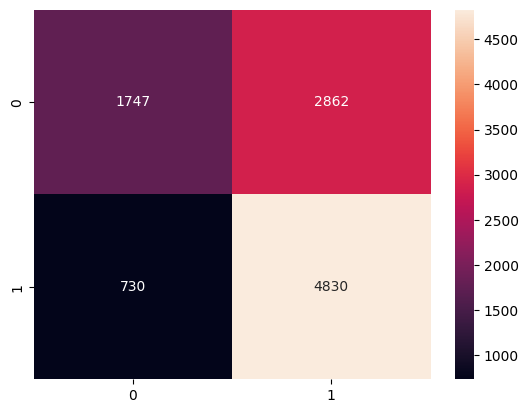

In [29]:
cm = confusion_matrix(y_test, y_pred)
plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.savefig('/tmp/cm.png')
with open('/tmp/cm.png', 'rb') as f:
    s3.put_object(Bucket=bucket_name, Key=f'models/cm.png', Body=f.read())

In [30]:
X_test.assign(actual=y_test, predicted=y_pred, proba=y_pred_proba).head(20).to_csv('/tmp/pred.csv')
with open('/tmp/pred.csv', 'rb') as f:
    s3.put_object(Bucket=bucket_name, Key=f'models/predictions.csv', Body=f.read())

Проверим, что файлы корректно добавлены

In [31]:
response = s3.list_objects_v2(Bucket=bucket_name, Prefix='models/')

if 'Contents' in response:
    print(f"Файлы в бакете {bucket_name} в папке models")
    for obj in response['Contents']:
        print(f"  - {obj['Key']} ({obj['Size']} bytes)")
else:
    print("Файлов не найдено")

Файлы в бакете checkpoint7 в папке models
  - models/cm.png (14737 bytes)
  - models/model.pkl (1669289 bytes)
  - models/predictions.csv (5859 bytes)
